# Notebook 2 — Metrische XGBoost-Baseline

**Ziel:** Entwicklung und Evaluation einer metrischen Baseline für die
Unterscheidung von `mali` gegenüber (`anom` + `norm`) auf CloudAnoBench.

**Methodische Kernelemente:**
- Nutzung ausschließlich der 5 universellen Features (`cpu_usage`, `mem_usage`,
  `disk_io`, `net_in`, `net_out`) zur Vermeidung von Schema-Leakage
- **Dreistufiger gruppenbasierter Split**: TrainVal/Test (gss1, rs=42) + Train/Val (gss2, rs=0)
- `scale_pos_weight`, Early Stopping und Threshold-Wahl **ausschließlich auf Train/Val**
- **Testset** dient ausschließlich der finalen Evaluation — keine Optimierung, kein Tuning
- Schwellenwertwahl: höchster Threshold mit `Recall ≥ 0.95` (auf **Validation**)
- Seed-Wahl für Val-Split ausschließlich anhand TrainVal-Klassenverteilung (kein Test-Zugriff)

**Input:** Bereinigte Parquet-Artefakte aus Notebook 1  
**Output:** `docs/split_assignments.csv`, `docs/metric_test_scores.csv`,
`docs/feature_importance_baseline.png`, `docs/pr_curve_baseline.png`

In [1]:
import pandas as pd
import os
import numpy as np
from xgboost import (XGBClassifier, plot_importance)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (recall_score, confusion_matrix, precision_recall_curve, average_precision_score, f1_score)
import time
import matplotlib.pyplot as plt

base_path = os.path.join(os.getcwd(), "..", "data")


# Daten laden
processed_path = os.path.join(base_path, "processed")

mali_clean = pd.read_parquet(os.path.join(processed_path, "mali_clean.parquet"))
anom_clean = pd.read_parquet(os.path.join(processed_path, "anom_clean.parquet"))
norm_clean = pd.read_parquet(os.path.join(processed_path, "norm_clean.parquet"))


print(mali_clean.shape, anom_clean.shape, norm_clean.shape)

(19384, 39) (41400, 39) (51208, 39)


In [2]:
# ─── Alle drei kombinieren ───────────────────────────────────────────────────
all_data = pd.concat([mali_clean, anom_clean, norm_clean], ignore_index=True)

# Gruppenkey: dataset_type + "_" + scenario_id — verhindert cross-dataset-Leakage
all_data['group_id'] = all_data['dataset_type'] + '_' + all_data['scenario_id'].astype(str)

# Nur die 5 universellen Features (in allen 3 Datasets vorhanden) — verhindert Schema-Leakage
feature_cols = sorted(['cpu_usage', 'mem_usage', 'disk_io', 'net_in', 'net_out'])

X      = all_data[feature_cols]
y      = all_data['label']
groups = all_data['group_id']

# ─── Split 1: TrainVal / Test ─────────────────────────────────────────────────
# test_size=0.20, random_state=42 — identisch zum bisherigen Split.
# → Testgruppen bleiben konsistent gegenüber dem vorherigen Stand.
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval      = X.iloc[trainval_idx]
X_test          = X.iloc[test_idx]
y_trainval      = y.iloc[trainval_idx]
y_test          = y.iloc[test_idx]
groups_trainval = groups.iloc[trainval_idx]
meta_test       = all_data[['dataset_type', 'scenario_id', 'case_id', 'group_id']].iloc[test_idx].reset_index(drop=True)

# ─── Split 2: Train / Validation (innerhalb TrainVal) ────────────────────────
# Seed wird ausschließlich anhand der TrainVal-Klassenverteilung geprüft.
# Kriterium: Val muss >= 10 positive Fälle enthalten — keine Testset-Sicht.
SEED_CANDIDATES = (0, 1, 2, 7, 42)
VAL_MIN_POS     = 10

def _pick_val_seed(X_tv, y_tv, groups_tv, seed_candidates, min_pos):
    """Gibt (seed, train_sub_idx, val_sub_idx) zurück.
    Nur TrainVal-Daten werden für die Seed-Entscheidung verwendet — kein Test-Zugriff."""
    for seed in seed_candidates:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
        tr_idx, vl_idx = next(gss.split(X_tv, y_tv, groups_tv))
        if y_tv.iloc[vl_idx].sum() >= min_pos:
            return seed, tr_idx, vl_idx
    raise ValueError(f"Kein Seed in {seed_candidates} liefert Val >= {min_pos} positive Fälle.")

val_seed, train_sub_idx, val_sub_idx = _pick_val_seed(
    X_trainval, y_trainval, groups_trainval, SEED_CANDIDATES, VAL_MIN_POS
)
print(f"Gewählter Val-Seed: {val_seed}  (erste aus {SEED_CANDIDATES} mit Val-Pos >= {VAL_MIN_POS})")

X_train = X_trainval.iloc[train_sub_idx]
X_val   = X_trainval.iloc[val_sub_idx]
y_train = y_trainval.iloc[train_sub_idx]
y_val   = y_trainval.iloc[val_sub_idx]
groups_train = groups_trainval.iloc[train_sub_idx]
groups_val   = groups_trainval.iloc[val_sub_idx]

# ─── scale_pos_weight ausschließlich aus Train ────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Train:       {X_train.shape}  | pos={pos}, neg={neg} → scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Validation:  {X_val.shape}   | pos={int(y_val.sum())}, neg={int((y_val==0).sum())}")
print(f"Test:        {X_test.shape}  | pos={int(y_test.sum())}, neg={int((y_test==0).sum())}")
print(f"\nTrain-Gruppen:  {groups_train.nunique()}")
print(f"Val-Gruppen:    {groups_val.nunique()}")
print(f"Test-Gruppen:   {groups.iloc[test_idx].nunique()}")

# ─── Gruppen-Disjunktheit sicherstellen ──────────────────────────────────────
_g_tr  = set(groups_train)
_g_val = set(groups_val)
_g_te  = set(groups.iloc[test_idx])
assert len(_g_tr & _g_val) == 0, "Leakage: Gruppen in Train und Val!"
assert len(_g_val & _g_te) == 0, "Leakage: Gruppen in Val und Test!"
assert len(_g_tr  & _g_te) == 0, "Leakage: Gruppen in Train und Test!"
print("✓ Train / Val / Test sind gruppen-disjunkt.")

# ─── Split-Artefakt speichern ─────────────────────────────────────────────────
docs_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)

case_meta_all = (all_data
                 .drop_duplicates(subset='case_id')
                 [['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']]
                 .reset_index(drop=True))

def _assign_split(gid):
    if gid in _g_tr:  return 'train'
    if gid in _g_val: return 'val'
    if gid in _g_te:  return 'test'
    return 'unknown'

case_meta_all['split'] = case_meta_all['group_id'].apply(_assign_split)
case_meta_all.to_csv(os.path.join(docs_path, "split_assignments.csv"), index=False)

print(f"\n✓ split_assignments.csv gespeichert ({len(case_meta_all)} Cases)")
print(case_meta_all['split'].value_counts().sort_index().to_string())
print(f"\nTest dataset breakdown (Zeilen):\n{all_data[['dataset_type']].iloc[test_idx]['dataset_type'].value_counts()}")

Gewählter Val-Seed: 0  (erste aus (0, 1, 2, 7, 42) mit Val-Pos >= 10)
Train:       (70694, 5)  | pos=10304, neg=60390 → scale_pos_weight: 5.86
Validation:  (18528, 5)   | pos=4760, neg=13768
Test:        (22770, 5)  | pos=4320, neg=18450

Train-Gruppen:  28
Val-Gruppen:    8
Test-Gruppen:   9
✓ Train / Val / Test sind gruppen-disjunkt.

✓ split_assignments.csv gespeichert (1252 Cases)
split
test     253
train    793
val      206

Test dataset breakdown (Zeilen):
dataset_type
norm    11610
anom     6840
mali     4320
Name: count, dtype: int64


In [3]:
model = XGBClassifier(
    n_estimators=300,          # Obergrenze; early stopping bestimmt echte Anzahl
    max_depth=6,               # Standard für tabellarische Daten; verhindert Overfitting
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',        # Histogram-basiert — effizienter bei 89k Samples
    eval_metric='aucpr',       # PR-AUC statt logloss: robuster bei 1:4.92-Ungleichgewicht
    early_stopping_rounds=20,  # Stoppt wenn aucpr sich 20 Runden nicht verbessert
    random_state=42,
    n_jobs=-1
)

# Early Stopping ausschließlich auf Validierungsset — kein Testset-Zugriff
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
print("Training abgeschlossen.")
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-aucpr:0.59053


[43]	validation_0-aucpr:0.60102


Training abgeschlossen.
Best iteration: 23


## Methodische Stärke: Dreistufige gruppenbasierte Aufteilung

| Split | Zweck |
|---|---|
| **Train** | XGBoost-Training, `scale_pos_weight`-Berechnung |
| **Validation** | Early Stopping (`eval_set`), Threshold-Wahl (Recall ≥ 0.95) |
| **Test** | Ausschließlich finale Evaluation — keine Optimierung, kein Tuning |

Diese strikte Trennung ist frei von Optimierungsbias gegenüber dem Testset
und entspricht korrekter ML-Evaluationspraxis (Arp et al., 2022).
Der `GroupShuffleSplit` stellt sicher, dass keine Gruppe in zwei verschiedenen
Splits erscheint (Schema-Leakage-Prävention).

Der Val-Seed wird ausschließlich anhand der TrainVal-Klassenverteilung
geprüft — kein Zugriff auf Testmetriken.

In [4]:
# ─── Threshold-Wahl auf Validierungsset ──────────────────────────────────────
# Testset wird hier nicht berührt.
y_proba_val = model.predict_proba(X_val)[:, 1]
precisions_val, recalls_val, thresholds_val = precision_recall_curve(y_val, y_proba_val)
ap_val = average_precision_score(y_val, y_proba_val)

valid_thr_val = thresholds_val[recalls_val[:-1] >= 0.95]
best_threshold_val = float(valid_thr_val.max()) if len(valid_thr_val) > 0 else float(thresholds_val[0])

print(f"Validation AP:               {ap_val:.4f}")
print(f"Threshold (Val, Rec≥0.95):   {best_threshold_val:.4f}")
print(f"Val-Recall @ Threshold:      {recall_score(y_val, (y_proba_val >= best_threshold_val).astype(int)):.4f}")

# ─── Finale Evaluation ausschließlich auf Testset ─────────────────────────────
t0 = time.time()
y_proba_test = model.predict_proba(X_test)[:, 1]
latency_ms = (time.time() - t0) * 1000

precisions_test, recalls_test, thresholds_test = precision_recall_curve(y_test, y_proba_test)
ap_test = average_precision_score(y_test, y_proba_test)

# Wende eingefrorenen Val-Threshold auf Test an
y_pred_test = (y_proba_test >= best_threshold_val).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
precision_at_t = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\n=== Finale Test-Evaluation (Threshold aus Validation) ===")
print(f"Average Precision (AP):      {ap_test:.4f}")
print(f"Threshold (aus Val):         {best_threshold_val:.4f}")
print(f"Test-Recall @ Threshold:     {recall_score(y_test, y_pred_test):.4f}")
print(f"Test-Precision:              {precision_at_t:.4f}")
print(f"Test-F1:                     {f1_score(y_test, y_pred_test):.4f}")
print(f"Test-Latenz:                 {latency_ms:.1f} ms  ({X_test.shape[0]} Samples, indikativ)")
print(f"Test-FPR (anom+norm):        {fp / (fp + tn):.4f}  ({fp} FP von {fp+tn})")

# ─── Audit-Artefakt: metric_test_scores.csv ──────────────────────────────────
metric_scores_df = meta_test.copy()
metric_scores_df['label']               = y_test.values
metric_scores_df['metric_score']        = y_proba_test
metric_scores_df['metric_pred']         = y_pred_test
metric_scores_df['threshold_metric_val'] = best_threshold_val
metric_scores_df.to_csv(os.path.join(docs_path, "metric_test_scores.csv"), index=False)
print(f"\n✓ metric_test_scores.csv gespeichert ({len(metric_scores_df)} Zeilen)")

# ─── Validierungsset-Scores speichern (für Threshold-Sensitivity-Analyse) ──────
val_idx_in_all   = trainval_idx[val_sub_idx]
meta_val         = all_data[['dataset_type', 'scenario_id', 'case_id', 'group_id']].iloc[val_idx_in_all].reset_index(drop=True)
metric_val_df    = meta_val.copy()
metric_val_df['label']        = y_val.values
metric_val_df['metric_score'] = y_proba_val
metric_val_df.to_csv(os.path.join(docs_path, "metric_val_scores.csv"), index=False)
print(f"✓ metric_val_scores.csv gespeichert ({len(metric_val_df)} Zeilen)")


Validation AP:               0.6231
Threshold (Val, Rec≥0.95):   0.0903
Val-Recall @ Threshold:      0.9500

=== Finale Test-Evaluation (Threshold aus Validation) ===
Average Precision (AP):      0.2565
Threshold (aus Val):         0.0903
Test-Recall @ Threshold:     0.9572
Test-Precision:              0.2308
Test-F1:                     0.3719
Test-Latenz:                 7.0 ms  (22770 Samples, indikativ)
Test-FPR (anom+norm):        0.7469  (13780 FP von 18450)



✓ metric_test_scores.csv gespeichert (22770 Zeilen)
✓ metric_val_scores.csv gespeichert (18528 Zeilen)


In [5]:
# ─── Threshold-Sensitivity-Analyse: Metrik-Komponente (Val-basiert, Zeilenebene) ─
# HINWEIS: Metriken hier auf ZEILENEBENE (je Zeitreihenpunkt). Case-Level-FPR
# nach max-Aggregation → in NB04. Threshold-Wahl ausschließlich aus Validation.
from sklearn.metrics import precision_score  # ergänzt für Sensitivity-Analyse

RECALL_TARGETS = [0.95, 0.975, 0.99, 1.00]

rows_m = []
for target in RECALL_TARGETS:
    valid_m = thresholds_val[recalls_val[:-1] >= target]
    if len(valid_m) > 0:
        thr_m = float(valid_m.max())
    else:
        thr_m = float(thresholds_val[0])

    val_rec_m = float(recall_score(y_val, (y_proba_val >= thr_m).astype(int)))
    y_pred_m  = (y_proba_test >= thr_m).astype(int)
    tn_m, fp_m, fn_m, tp_m = confusion_matrix(y_test, y_pred_m).ravel()

    rows_m.append({
        'target_recall_val': target,
        'threshold_val':     round(thr_m, 6),
        'val_recall':        round(val_rec_m, 4),
        'test_recall':       round(recall_score(y_test, y_pred_m), 4),
        'test_fpr':          round(fp_m / (fp_m + tn_m), 4) if (fp_m + tn_m) > 0 else 0,
        'test_precision':    round(precision_score(y_test, y_pred_m, zero_division=0), 4),
        'test_f1':           round(f1_score(y_test, y_pred_m, zero_division=0), 4),
        'TP': int(tp_m), 'FP': int(fp_m), 'TN': int(tn_m), 'FN': int(fn_m)
    })

sensitivity_metric_df = pd.DataFrame(rows_m)
sensitivity_metric_df.to_csv(os.path.join(docs_path, "threshold_sensitivity_metric.csv"), index=False)
print("=== Metrik-Threshold-Sensitivity (Val-basiert, Zeilenebene) ===")
print(sensitivity_metric_df.to_string(index=False))
print(f"\n✓ threshold_sensitivity_metric.csv gespeichert")

=== Metrik-Threshold-Sensitivity (Val-basiert, Zeilenebene) ===


 target_recall_val  threshold_val  val_recall  test_recall  test_fpr  test_precision  test_f1   TP    FP   TN  FN
             0.950       0.090309      0.9500       0.9572    0.7469          0.2308   0.3719 4135 13780 4670 185
             0.975       0.057001      0.9752       0.9942    0.9112          0.2035   0.3378 4295 16811 1639  25
             0.990       0.049919      0.9981       0.9975    0.9690          0.1942   0.3251 4309 17878  572  11
             1.000       0.044735      1.0000       1.0000    0.9804          0.1928   0.3233 4320 18088  362   0

✓ threshold_sensitivity_metric.csv gespeichert


In [6]:
# FPR getrennt nach Dataset-Typ: prüft ob Modell zwischen technischen
# Anomalien (anom) und normalen Lastspitzen (norm) unterscheidet.
#
# WICHTIG — Granularität:
# Diese FPR-Werte sind auf ZEILENEBENE berechnet (je Metrik-Zeitreihenpunkt).
# total_sub entspricht der Anzahl der Zeilen pro Typ, nicht der Anzahl der Cases.
# Die Case-Ebene-FPR (1 Entscheidung pro Case, nach Max-Aggregation) wird erst
# im Fusions-Notebook (Notebook 4) berichtet.
for dtype in ['anom', 'norm']:
    mask = (meta_test['dataset_type'] == dtype).values
    fp_sub = y_pred_test[mask].sum()
    total_sub = mask.sum()
    print(f"FPR {dtype} (Zeilenebene): {fp_sub / total_sub:.4f}  ({fp_sub} FP von {total_sub} Zeilen)")

FPR anom (Zeilenebene): 0.8133  (5563 FP von 6840 Zeilen)
FPR norm (Zeilenebene): 0.7078  (8217 FP von 11610 Zeilen)


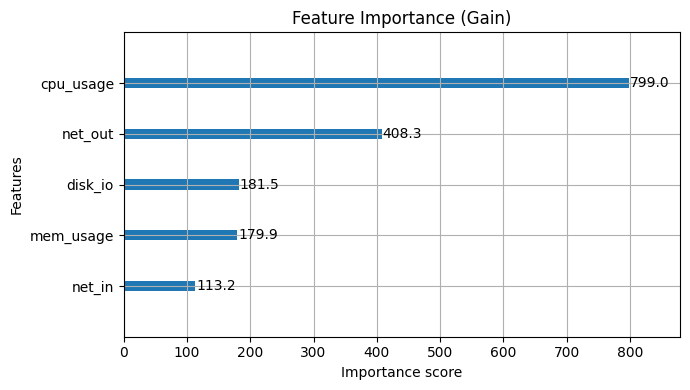

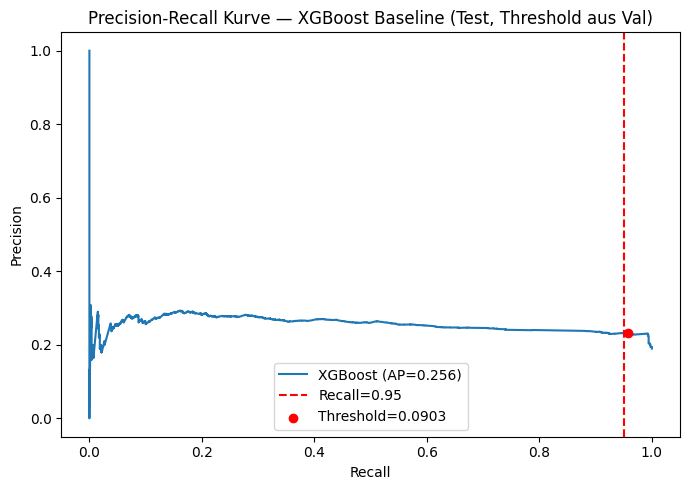

In [7]:
# docs_path bereits in Cell 2 definiert
os.makedirs(docs_path, exist_ok=True)

# Feature Importance
fig, ax = plt.subplots(figsize=(7, 4))

# gain: mittlere Verbesserung des Loss pro Split — aussagekräftiger als Splitting-Häufigkeit (weight)
plot_importance(model, ax=ax, importance_type='gain', title='Feature Importance (Gain)', values_format='{v:.1f}')
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "feature_importance_baseline.png"), dpi=150)
plt.show()

# Precision-Recall Kurve (auf Testset, Threshold aus Validation)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls_test, precisions_test, label=f'XGBoost (AP={ap_test:.3f})')
ax.axvline(x=0.95, color='red', linestyle='--', label='Recall=0.95')
ax.scatter([recall_score(y_test, y_pred_test)],
           [tp / (tp + fp) if (tp + fp) > 0 else 0],
           color='red', zorder=5, label=f'Threshold={best_threshold_val:.4f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurve — XGBoost Baseline (Test, Threshold aus Val)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "pr_curve_baseline.png"), dpi=150)
plt.show()

## Ergebnis der metrischen Baseline

*Aktuelle Werte nach dem Ausführen der Zellen oben ablesen.*

| Metrik | Quelle |
|---|---|
| Val-AP | Cell 5 Output |
| Test-AP | Cell 5 Output |
| Test-Recall @ Val-Threshold | Cell 5 Output |
| Test-Precision | Cell 5 Output |
| Test-F1 | Cell 5 Output |
| Test-FPR (Zeilenebene) | Cell 5 + Cell 6 Output |
| Val-Threshold | Cell 5 Output |
| scale_pos_weight | Cell 2 Output |
| Best Iteration (Early Stopping) | Cell 3 Output |

**Methodik:** Threshold und Early Stopping wurden ausschließlich auf dem
Validierungsset bestimmt. Das Testset wurde erst in Cell 5 berührt —
ausschließlich für die finale Evaluation. Kein Optimierungsbias gegenüber dem Testset.

Diese Ausgangslage motiviert **Notebook 3**: Die Log-Dateien werden dort
als zusätzliche Verifikationsschicht auf Case-Ebene eingesetzt,
um Fehlalarme zu reduzieren, ohne den Recall wesentlich zu senken.